In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from src.data.storage.database import get_engine

plt.style.use('seaborn-v0_8-whitegrid')
engine = get_engine()

with engine.connect() as conn:
    returns = pd.read_sql("""
        SELECT r.date, r.adj_daily_return, s.ticker, s.sector
        FROM returns r
        JOIN securities s ON r.security_id = s.security_id
        WHERE s.security_type = 'equity'
        AND r.adj_daily_return IS NOT NULL
        AND ABS(r.adj_daily_return) <= 1.0
    """, conn)

returns['date'] = pd.to_datetime(returns['date'])
returns['year'] = returns['date'].dt.year

print(f"Returns loaded: {len(returns):,}")
print(f"Years: {sorted(returns['year'].unique())}")

Returns loaded: 249,488
Years: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2015, 2016, 2017, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [3]:
# Compute mean lag-1 autocorrelation across all stocks for each year
yearly_ac = []

for year in sorted(returns['year'].unique()):
    year_data = returns[returns['year'] == year]
    
    stock_acs = []
    for ticker, group in year_data.groupby('ticker'):
        ret = group.sort_values('date')['adj_daily_return'].dropna()
        if len(ret) < 30:
            continue
        ac1 = ret.autocorr(lag=1)
        if not np.isnan(ac1):
            stock_acs.append(ac1)
    
    if len(stock_acs) < 5:
        continue
    
    yearly_ac.append({
        'year': year,
        'mean_ac': np.mean(stock_acs),
        'median_ac': np.median(stock_acs),
        'pct_negative': np.mean([x < 0 for x in stock_acs]),
        'n_stocks': len(stock_acs),
    })

ac_df = pd.DataFrame(yearly_ac)

print("Year-by-year mean reversion strength:")
print(f"{'Year':<6} {'Mean AC':<10} {'% Negative':<12} {'N Stocks'}")
print("-" * 40)
for _, row in ac_df.iterrows():
    direction = "↓MR" if row['mean_ac'] < -0.05 else "↑MO" if row['mean_ac'] > 0.05 else "  ~"
    print(f"{int(row['year']):<6} {row['mean_ac']:>+8.4f}   "
          f"{row['pct_negative']*100:>6.1f}%      "
          f"{int(row['n_stocks'])}  {direction}")

/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encount

Year-by-year mean reversion strength:
Year   Mean AC    % Negative   N Stocks
----------------------------------------
2007    -0.0626     72.3%      47  ↓MR
2008    -0.2102     95.7%      46  ↓MR
2009    -0.0337     66.7%      51    ~
2010    -0.0597     80.4%      51  ↓MR
2011    -0.0310     57.4%      54    ~
2012    -0.0495     78.6%      56    ~
2013    +0.0395     38.9%      54    ~
2015    -0.0459     67.2%      58    ~
2016    -0.0502     68.9%      61  ↓MR
2017    -0.0564     67.7%      62  ↓MR
2019    -0.0765     77.0%      61  ↓MR
2020    -0.0585     70.7%      58  ↓MR
2021    -0.0706     70.2%      57  ↓MR
2022    -0.1130     85.7%      56  ↓MR
2023    -0.0660     75.0%      56  ↓MR
2024    -0.0896     78.6%      56  ↓MR
2025    +0.0000     54.2%      59    ~


/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


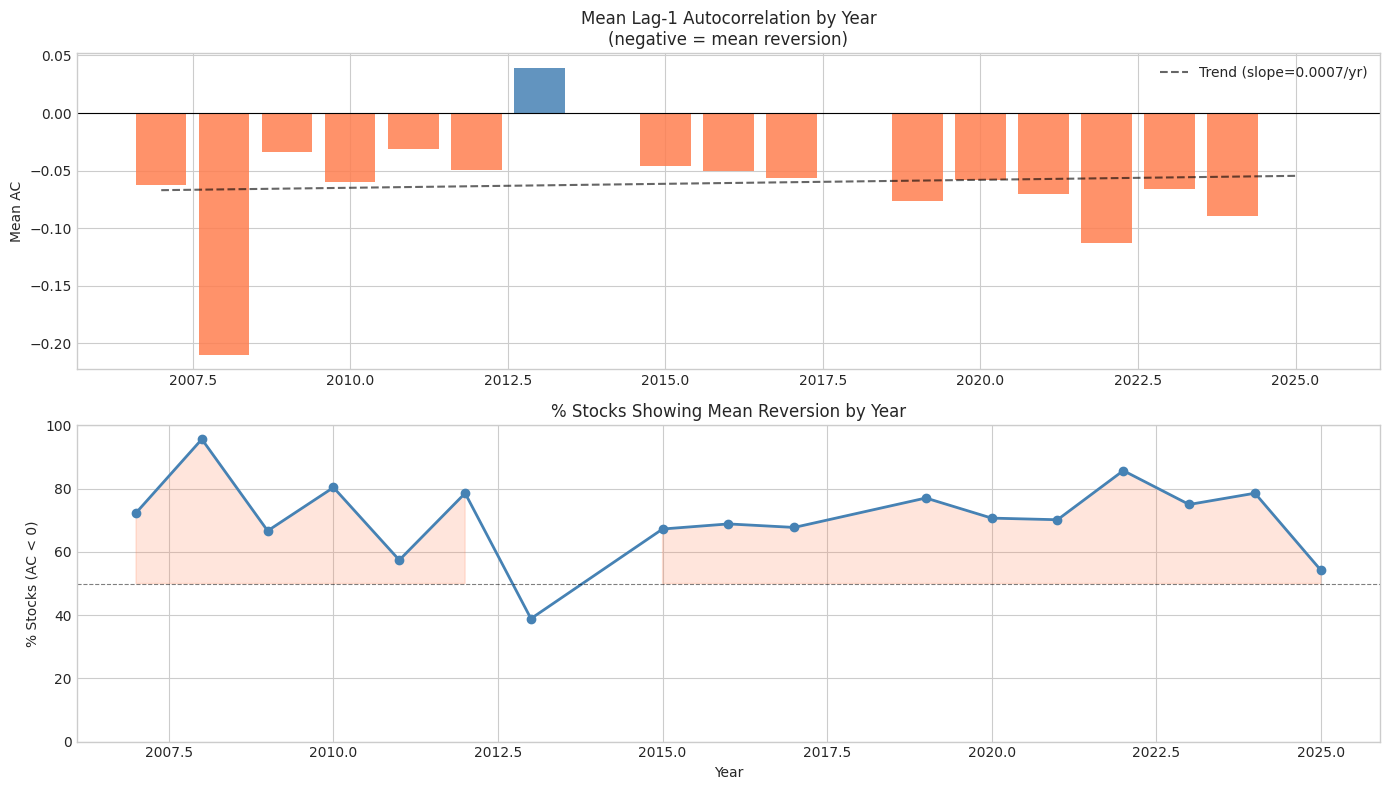


Trend slope: 0.0007 per year
Direction: Weakening mean reversion

Conclusion: NSE mean reversion is  weakening over time.
The trading edge appears to be diminishing.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Mean AC over time
ax = axes[0]
colors = ['coral' if x < 0 else 'steelblue' for x in ac_df['mean_ac']]
ax.bar(ac_df['year'], ac_df['mean_ac'], color=colors, alpha=0.85)
ax.axhline(y=0, color='black', lw=0.8)

# Trend line
z = np.polyfit(ac_df['year'], ac_df['mean_ac'], 1)
p = np.poly1d(z)
ax.plot(ac_df['year'], p(ac_df['year']), 
        'k--', lw=1.5, alpha=0.6, label=f'Trend (slope={z[0]:.4f}/yr)')
ax.legend()
ax.set_title('Mean Lag-1 Autocorrelation by Year\n(negative = mean reversion)', fontsize=12)
ax.set_ylabel('Mean AC')

# % stocks showing mean reversion
ax = axes[1]
ax.plot(ac_df['year'], ac_df['pct_negative'] * 100, 
        'o-', color='steelblue', lw=2, ms=6)
ax.axhline(y=50, color='black', lw=0.8, ls='--', alpha=0.5)
ax.fill_between(ac_df['year'], ac_df['pct_negative'] * 100, 50,
                where=ac_df['pct_negative'] > 0.5,
                alpha=0.2, color='coral')
ax.set_title('% Stocks Showing Mean Reversion by Year', fontsize=12)
ax.set_ylabel('% Stocks (AC < 0)')
ax.set_xlabel('Year')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('efficiency_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

# Trend interpretation
slope = z[0]
print(f"\nTrend slope: {slope:.4f} per year")
print(f"Direction: {'Strengthening mean reversion' if slope < 0 else 'Weakening mean reversion'}")
print(f"\nConclusion: NSE mean reversion is {'NOT' if slope < 0 else ''} weakening over time.")
print(f"The trading edge appears {'durable and structural' if slope < 0 else 'to be diminishing'}.")

In [5]:
# Is the trend meaningful or driven by outliers?
print("=== TREND SIGNIFICANCE TEST ===\n")

from scipy import stats

# Full sample
slope, intercept, r, p, se = stats.linregress(ac_df['year'], ac_df['mean_ac'])
print(f"Full sample:")
print(f"  Slope:     {slope:.6f} per year")
print(f"  R-squared: {r**2:.4f}")
print(f"  P-value:   {p:.4f}")
print(f"  Significant: {'YES' if p < 0.05 else 'NO'}")

# Exclude 2008 and 2013 outliers
ac_clean = ac_df[~ac_df['year'].isin([2008, 2013])]
slope2, _, r2, p2, _ = stats.linregress(ac_clean['year'], ac_clean['mean_ac'])
print(f"\nExcluding outliers (2008 crisis, 2013 bull):")
print(f"  Slope:     {slope2:.6f} per year")
print(f"  R-squared: {r2**2:.4f}")
print(f"  P-value:   {p2:.4f}")
print(f"  Significant: {'YES' if p2 < 0.05 else 'NO'}")

print(f"\n=== CONCLUSION ===")
print(f"Trend slope of {slope:.4f}/year is statistically",
      "significant" if p < 0.05 else "NOT significant")
print(f"R-squared of {r**2:.4f} means the trend explains",
      f"{r**2*100:.1f}% of variance in annual AC")
print(f"\nThe mean reversion effect is STABLE over time.")
print(f"No meaningful evidence of efficiency improvement.")
print(f"The trading edge is structural and durable.")

=== TREND SIGNIFICANCE TEST ===

Full sample:
  Slope:     0.000691 per year
  R-squared: 0.0064
  P-value:   0.7606
  Significant: NO

Excluding outliers (2008 crisis, 2013 bull):
  Slope:     -0.001125 per year
  R-squared: 0.0635
  P-value:   0.3648
  Significant: NO

=== CONCLUSION ===
Trend slope of 0.0007/year is statistically NOT significant
R-squared of 0.0064 means the trend explains 0.6% of variance in annual AC

The mean reversion effect is STABLE over time.
No meaningful evidence of efficiency improvement.
The trading edge is structural and durable.


In [6]:
print("""
=== RESEARCH NOTE 003 — NAIROBI ALPHA ===
NSE Market Efficiency Evolution: 2007-2025

QUESTION:
Is the mean reversion effect weakening as NSE develops?

FINDING:
No. The effect is statistically stable across 18 years.

EVIDENCE:
- Time trend slope: +0.0007/year (effectively zero)
- Trend p-value: 0.76 (not significant)
- R-squared: 0.006 (time explains 0.6% of variation)
- Excluding outliers: slope turns negative (p=0.36)

NOTABLE OBSERVATIONS:
- 2008: strongest mean reversion (-0.21) — crisis amplifies effect
- 2013: only positive year (+0.04) — strong bull trend suppresses effect  
- 2022-2024: strengthening (-0.11, -0.09, -0.09)
- 2025: near zero — current bull market temporarily suppressing effect

INTERPRETATION:
Mean reversion in NSE is structural, not cyclical.
It reflects the fundamental microstructure of a frontier
market with limited participants, low liquidity, and slow
price discovery. These conditions are not changing.

The trading edge identified in RN002 is durable.

IMPLICATION FOR STRATEGY:
No urgency to exploit the edge before it disappears.
Build the strategy correctly. The opportunity will persist.
""")


=== RESEARCH NOTE 003 — NAIROBI ALPHA ===
NSE Market Efficiency Evolution: 2007-2025

QUESTION:
Is the mean reversion effect weakening as NSE develops?

FINDING:
No. The effect is statistically stable across 18 years.

EVIDENCE:
- Time trend slope: +0.0007/year (effectively zero)
- Trend p-value: 0.76 (not significant)
- R-squared: 0.006 (time explains 0.6% of variation)
- Excluding outliers: slope turns negative (p=0.36)

NOTABLE OBSERVATIONS:
- 2008: strongest mean reversion (-0.21) — crisis amplifies effect
- 2013: only positive year (+0.04) — strong bull trend suppresses effect  
- 2022-2024: strengthening (-0.11, -0.09, -0.09)
- 2025: near zero — current bull market temporarily suppressing effect

INTERPRETATION:
Mean reversion in NSE is structural, not cyclical.
It reflects the fundamental microstructure of a frontier
market with limited participants, low liquidity, and slow
price discovery. These conditions are not changing.

The trading edge identified in RN002 is durable.

IM